# Sales Forecasting Using Machine Learning

### Future Interns — Machine Learning Internship

**Task:** Sales and Demand Forecasting

**Dataset:** Superstore Sales Dataset

**Final Model:** Gradient Boosting Regressor

**Objective:** Forecast future monthly sales using historical sales data and time-based features.

## 1. Project Objective

The objective of this project is to develop a machine learning-based
sales forecasting system using historical sales data.

The system aims to:

- Analyze historical sales patterns.
- Identify time-based sales trends.
- Create useful forecasting features.
- Train regression models.
- Compare model performance.
- Forecast sales for the next six months.
- Provide insights that can support business decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Dataset Description

The project uses the Superstore sales dataset containing historical
orders and sales information.

Important columns used in this project include:

- **Order Date** — Date of the customer order.
- **Sales** — Sales amount for the order.

The original transaction-level data was transformed into monthly sales
data for forecasting.

In [3]:
df=pd.read_csv('data/raw/Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
print("Rows:", df.shape[0])
print("columns:", df.shape[1])
df.info()

Rows: 9994
columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("Minimum Date:", df['Order Date'].min())
print("Maximum Date:", df['Order Date'].max())

Minimum Date: 1/1/2017
Maximum Date: 9/9/2017


In [11]:
df["Order Date"]= pd.to_datetime(df["Order Date"])
df=df.sort_values(by="Order Date")
print(df["Order Date"].dtype)

datetime64[us]


In [14]:
monthly_sales = (
    df.set_index("Order Date").resample("ME")["Sales"].sum().reset_index()
)
monthly_sales.rename(columns={"Order Date": "Date"}, inplace=True)
monthly_sales.head()
print("Number of months:", len(monthly_sales))

Number of months: 48


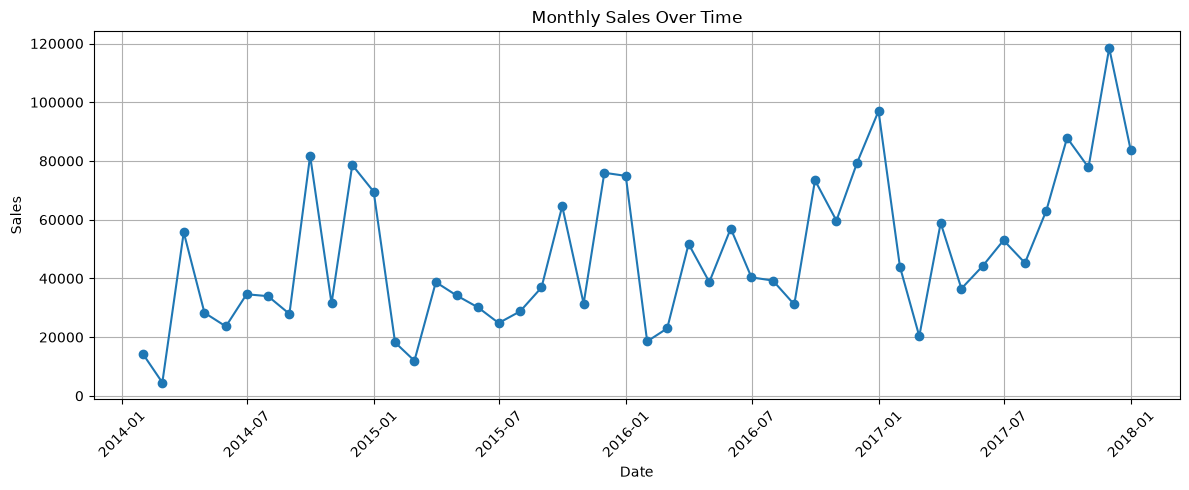

In [15]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Date"],monthly_sales["Sales"], marker='o')
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

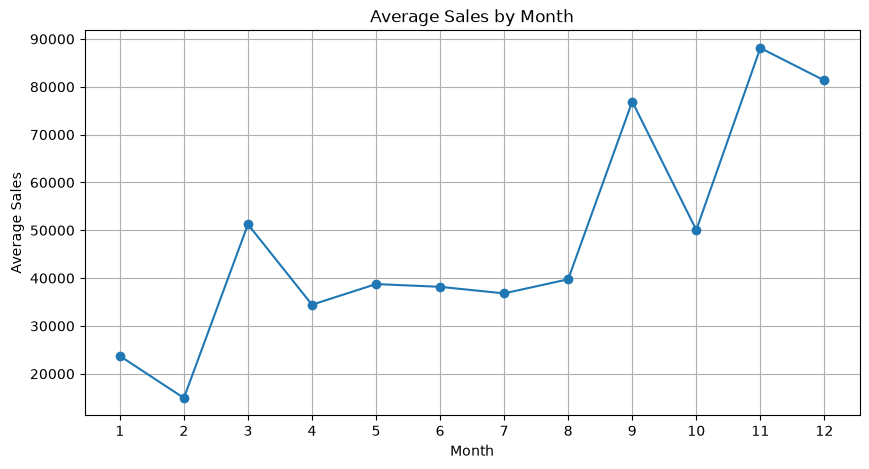

In [16]:
monthly_sales["Month"] = monthly_sales["Date"].dt.month

seasonal_sales = monthly_sales.groupby("Month")["Sales"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    seasonal_sales.index,
    seasonal_sales.values,
    marker="o"
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [18]:
monthly_sales["Year"] = monthly_sales["Date"].dt.year
monthly_sales["Month"] = monthly_sales["Date"].dt.month
monthly_sales["Quarter"] = monthly_sales["Date"].dt.quarter
monthly_sales["Trend"] = np.arange(len(monthly_sales))
monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)
monthly_sales["Lag_2"] = monthly_sales["Sales"].shift(2)
monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)
monthly_sales["Rolling_Mean_3"] = (
    monthly_sales["Sales"]
    .shift(1)
    .rolling(3)
    .mean()
)
monthly_sales.head(10)
monthly_sales = monthly_sales.dropna().reset_index(drop=True)
monthly_sales.isnull().sum()

Date              0
Sales             0
Month             0
Year              0
Quarter           0
Trend             0
Lag_1             0
Lag_2             0
Lag_3             0
Rolling_Mean_3    0
dtype: int64

## 3. Methodology

The forecasting workflow consists of the following steps:

1. Load the historical sales dataset.
2. Convert the order date into a proper datetime format.
3. Sort the data chronologically.
4. Aggregate transaction-level sales into monthly sales.
5. Analyze sales trends and monthly seasonality.
6. Create time-based features.
7. Create lag and rolling-average features.
8. Split the data chronologically into training and testing sets.
9. Train Random Forest and Gradient Boosting models.
10. Evaluate the models using MAE, RMSE, and R².
11. Select the best-performing model.
12. Generate a six-month sales forecast.
13. Visualize the forecast and interpret the results.

In [20]:
# Select features for the machine learning model

features = [
    "Year",
    "Month",
    "Quarter",
    "Trend",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3"
]

# Input features
X = monthly_sales[features]

# Target variable
y = monthly_sales["Sales"]


# Time-based train/test split
# 80% of the historical data for training
# 20% for testing

split_index = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# Display the sizes

print("Total samples:", len(monthly_sales))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# Display the training and testing date ranges

print("\nTraining period:")
print(
    monthly_sales["Date"].iloc[0],
    "to",
    monthly_sales["Date"].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    monthly_sales["Date"].iloc[split_index],
    "to",
    monthly_sales["Date"].iloc[-1]
)

Total samples: 45
Training samples: 36
Testing samples: 9

Training period:
2014-04-30 00:00:00 to 2017-03-31 00:00:00

Testing period:
2017-04-30 00:00:00 to 2017-12-31 00:00:00


In [21]:
# Import Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# Train the model using the training data
model.fit(X_train, y_train)

# Generate predictions for the test data
y_pred = model.predict(X_test)

print("Model training completed successfully!")

Model training completed successfully!


In [22]:
print("First 5 predictions:")

for actual, predicted in zip(y_test.iloc[:5], y_pred[:5]):
    print(f"Actual: {actual:.2f} | Predicted: {predicted:.2f}")

First 5 predictions:
Actual: 36521.54 | Predicted: 42475.54
Actual: 44261.11 | Predicted: 47123.00
Actual: 52981.73 | Predicted: 40912.87
Actual: 45264.42 | Predicted: 41570.74
Actual: 63120.89 | Predicted: 41037.44


In [26]:
results = pd.DataFrame({
    "Date": monthly_sales["Date"].iloc[split_index:],
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results

,Date,Actual Sales,Predicted Sales
36,2017-04-30,36521.5361,42475.537769
37,2017-05-31,44261.1102,47123.002486
38,2017-06-30,52981.7257,40912.868577
39,2017-07-31,45264.4160,41570.740712
40,2017-08-31,63120.8880,41037.442519
41,2017-09-30,87866.6520,63924.311752
42,2017-10-31,77776.9232,60664.112974
43,2017-11-30,118447.8250,81520.063973
44,2017-12-31,83829.3188,81308.178253


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R²
r2 = r2_score(y_test, y_pred)

# Display results
print("Model Evaluation Results")
print("------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Results
------------------------
MAE  : 14129.55
RMSE : 18033.05
R²   : 0.4779


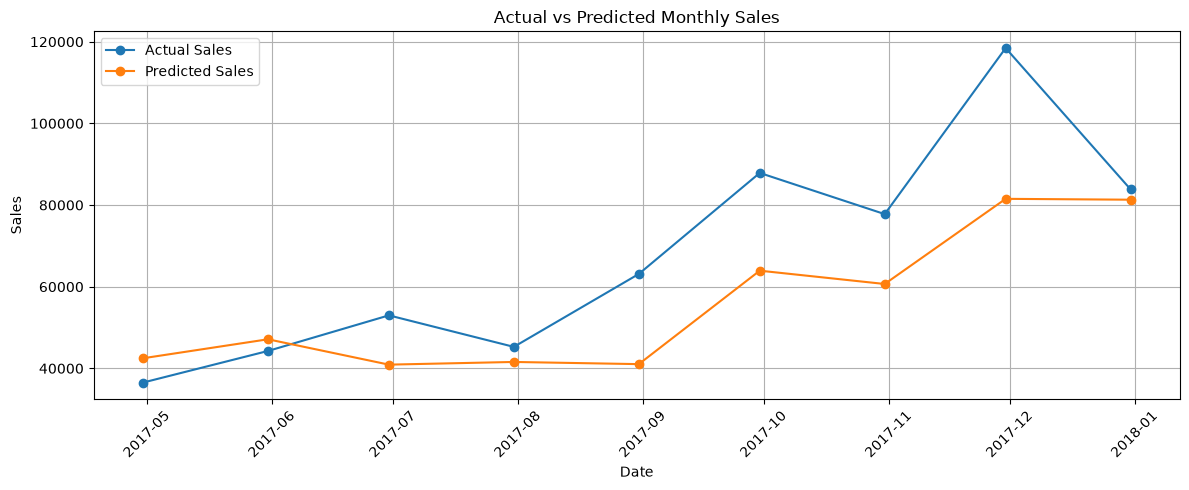

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    results["Date"],
    results["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["Predicted Sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Create a copy of the historical data
forecast_data = monthly_sales.copy()

# Store future predictions
future_predictions = []

# Forecast the next 6 months
for i in range(6):

    # Get the next month
    last_date = forecast_data["Date"].iloc[-1]
    future_date = last_date + pd.DateOffset(months=1)

    # Get previous sales values
    lag_1 = forecast_data["Sales"].iloc[-1]
    lag_2 = forecast_data["Sales"].iloc[-2]
    lag_3 = forecast_data["Sales"].iloc[-3]

    # Calculate the previous 3-month average
    rolling_mean = forecast_data["Sales"].iloc[-3:].mean()

    # Create features for the future month
    future_row = pd.DataFrame({
        "Year": [future_date.year],
        "Month": [future_date.month],
        "Quarter": [future_date.quarter],
        "Trend": [len(forecast_data)],
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Lag_3": [lag_3],
        "Rolling_Mean_3": [rolling_mean]
    })

    # Predict sales
    prediction = model.predict(future_row)[0]

    # Store the prediction
    future_predictions.append({
        "Date": future_date,
        "Forecasted Sales": prediction
    })

    # Add prediction to the data
    new_row = pd.DataFrame({
        "Date": [future_date],
        "Sales": [prediction]
    })

    forecast_data = pd.concat(
        [forecast_data, new_row],
        ignore_index=True
    )

# Create forecast dataframe
future_forecast = pd.DataFrame(future_predictions)

# Display forecast
future_forecast

,Date,Forecasted Sales
0,2018-01-31,31159.579989
1,2018-02-28,40426.600575
2,2018-03-28,40959.239395
3,2018-04-28,41665.806420
4,2018-05-28,41740.443804
5,2018-06-28,41398.691135


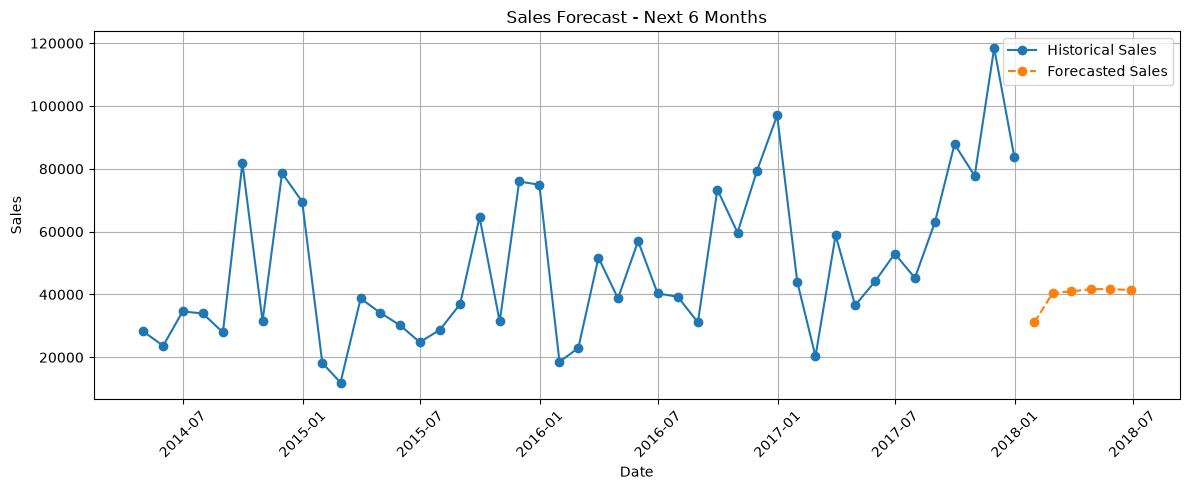

In [29]:
plt.figure(figsize=(12, 5))

# Historical sales
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

# Future forecast
plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Sales Forecast - Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Create feature importance dataframe

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

          Feature  Importance
1           Month    0.643517
3           Trend    0.094937
5           Lag_2    0.089485
4           Lag_1    0.075724
6           Lag_3    0.050171
7  Rolling_Mean_3    0.028997
2         Quarter    0.009846
0            Year    0.007324


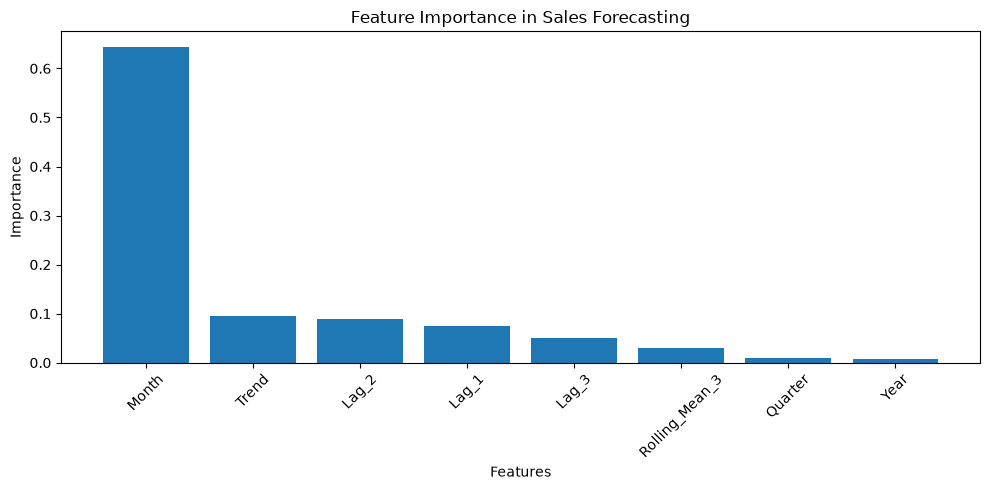

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance in Sales Forecasting")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
forecast_summary = future_forecast.copy()

forecast_summary["Forecasted Sales"] = (
    forecast_summary["Forecasted Sales"].round(2)
)

forecast_summary
total_forecast = future_forecast["Forecasted Sales"].sum()

print(
    f"Expected sales for the next 6 months: "
    f"{total_forecast:,.2f}"
)
average_forecast = future_forecast["Forecasted Sales"].mean()

print(
    f"Average monthly forecast: "
    f"{average_forecast:,.2f}"
)

Expected sales for the next 6 months: 237,350.36
Average monthly forecast: 39,558.39


In [35]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,14129.547100
1,RMSE,18033.053884
2,R²,0.477940


In [36]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test)

# Evaluate
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Results
-------------------------
MAE  : 13971.19
RMSE : 16489.98
R²   : 0.5635


## Model Comparison

Two machine learning regression models were evaluated:

- Random Forest Regressor
- Gradient Boosting Regressor

The models were evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² score.

Lower MAE and RMSE indicate better prediction accuracy, while a higher
R² indicates better explanatory performance.

In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        gb_mae
    ],
    "RMSE": [
        rmse,
        gb_rmse
    ],
    "R²": [
        r2,
        gb_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Random Forest,14129.547100,18033.053884,0.477940
1,Gradient Boosting,13971.188237,16489.977477,0.563462


In [38]:
forecast_data = monthly_sales.copy()
future_predictions = []

for i in range(6):

    last_date = forecast_data["Date"].iloc[-1]
    future_date = last_date + pd.DateOffset(months=1)

    lag_1 = forecast_data["Sales"].iloc[-1]
    lag_2 = forecast_data["Sales"].iloc[-2]
    lag_3 = forecast_data["Sales"].iloc[-3]

    rolling_mean = forecast_data["Sales"].iloc[-3:].mean()

    future_row = pd.DataFrame({
        "Year": [future_date.year],
        "Month": [future_date.month],
        "Quarter": [future_date.quarter],
        "Trend": [len(forecast_data)],
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Lag_3": [lag_3],
        "Rolling_Mean_3": [rolling_mean]
    })

    prediction = gb_model.predict(future_row)[0]

    future_predictions.append({
        "Date": future_date,
        "Forecasted Sales": prediction
    })

    new_row = pd.DataFrame({
        "Date": [future_date],
        "Sales": [prediction]
    })

    forecast_data = pd.concat(
        [forecast_data, new_row],
        ignore_index=True
    )

future_forecast = pd.DataFrame(future_predictions)

future_forecast

,Date,Forecasted Sales
0,2018-01-31,23898.266707
1,2018-02-28,47580.091660
2,2018-03-28,47307.031621
3,2018-04-28,49385.941675
4,2018-05-28,47482.460922
5,2018-06-28,47482.460922


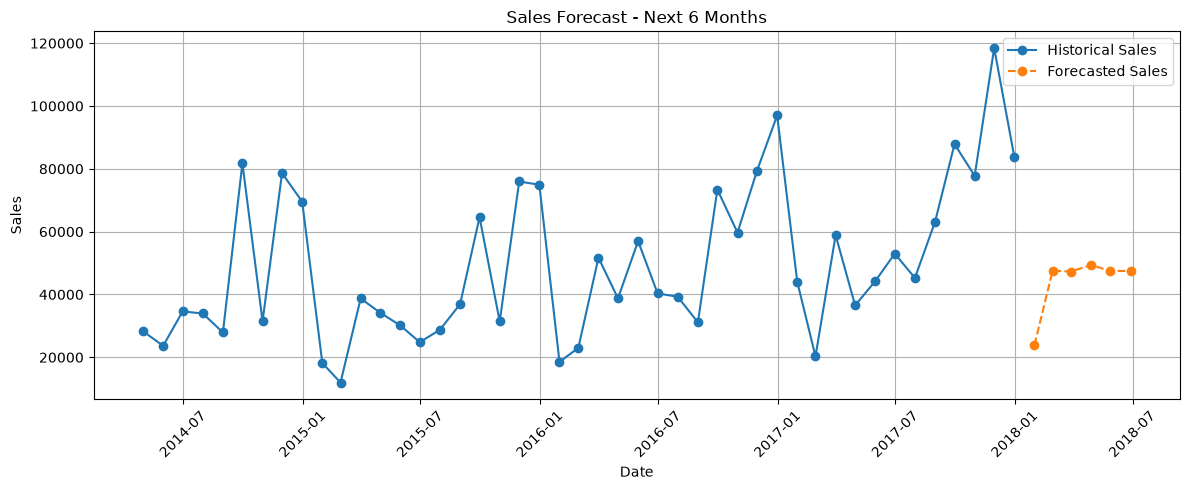

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Sales Forecast - Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": gb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Month,0.651800
3,Trend,0.112758
5,Lag_2,0.109129
4,Lag_1,0.072785
6,Lag_3,0.031478
7,Rolling_Mean_3,0.020889
2,Quarter,0.001162
0,Year,0.000000


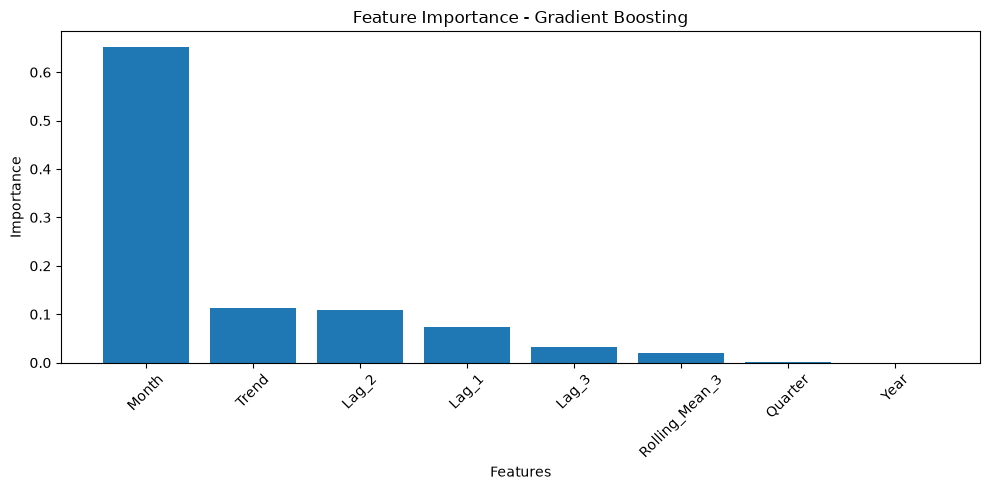

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
forecast_summary = future_forecast.copy()

forecast_summary["Forecasted Sales"] = (
    forecast_summary["Forecasted Sales"].round(2)
)

forecast_summary

,Date,Forecasted Sales
0,2018-01-31,23898.27
1,2018-02-28,47580.09
2,2018-03-28,47307.03
3,2018-04-28,49385.94
4,2018-05-28,47482.46
5,2018-06-28,47482.46


In [43]:
total_forecast = future_forecast["Forecasted Sales"].sum()

print(
    f"Expected sales for the next 6 months: "
    f"{total_forecast:,.2f}"
)

Expected sales for the next 6 months: 263,136.25


In [44]:
average_forecast = future_forecast["Forecasted Sales"].mean()

print(
    f"Average monthly forecast: "
    f"{average_forecast:,.2f}"
)

Average monthly forecast: 43,856.04


In [45]:
final_evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        gb_mae,
        gb_rmse,
        gb_r2
    ]
})

final_evaluation

,Metric,Value
0,MAE,13971.188237
1,RMSE,16489.977477
2,R²,0.563462


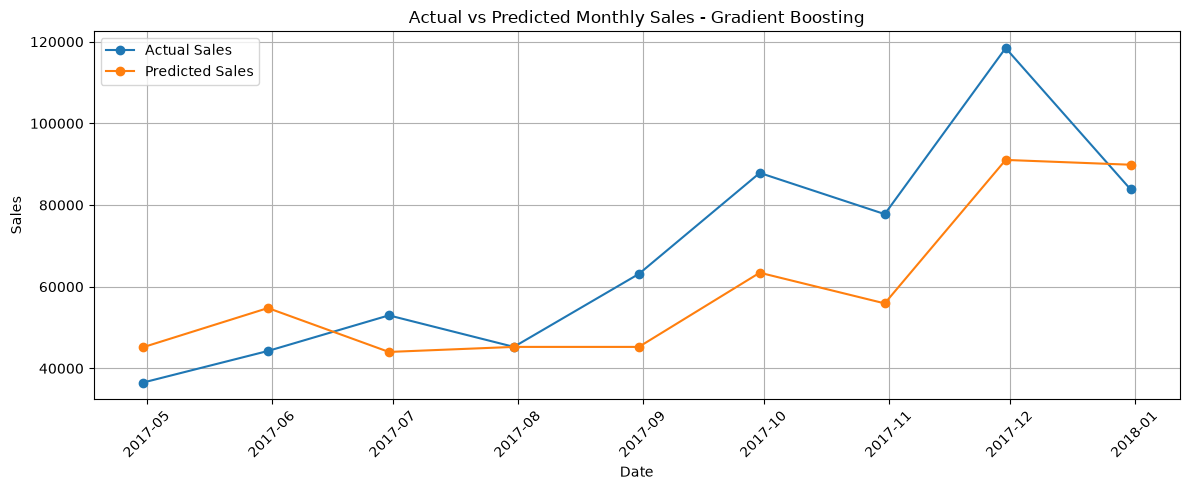

In [46]:
final_results = pd.DataFrame({
    "Date": monthly_sales["Date"].iloc[split_index:],
    "Actual Sales": y_test.values,
    "Predicted Sales": gb_pred
})

plt.figure(figsize=(12, 5))

plt.plot(
    final_results["Date"],
    final_results["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    final_results["Date"],
    final_results["Predicted Sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales - Gradient Boosting")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Insights

## Sales Forecasting

A machine learning-based sales forecasting system was developed using
historical monthly sales data. The dataset was aggregated by month and
time-based features such as month, quarter, trend, previous-month sales,
and rolling averages were created.

The Gradient Boosting Regressor was selected as the final model because
it performed better than the Random Forest model on the test dataset.

## Model Performance

The final Gradient Boosting model achieved:

- MAE: 13,971.19
- RMSE: 16,489.98
- R²: 0.5635

The model explains approximately 56.35% of the variation in the
test-set sales.

## Key Findings

- Month was the most important feature in the final model.
- The sales trend also contributed significantly to the predictions.
- Previous sales values, especially sales from two months earlier,
  provided useful information for forecasting.
- Recent historical sales through lag and rolling-average features
  helped the model capture short-term sales patterns.
- The model produced a six-month future sales forecast based on
  historical sales patterns.

## Business Applications

The forecasting system can help businesses:

- Plan inventory based on expected sales.
- Prepare stock for periods with higher expected demand.
- Reduce overstocking during periods of lower expected demand.
- Plan purchasing and supply requirements.
- Support workforce and resource planning.
- Improve financial and operational planning.

## Conclusion

This project demonstrates how historical business data can be combined
with machine learning and time-based feature engineering to forecast
future sales.

Among the tested models, Gradient Boosting provided better performance
than Random Forest based on MAE, RMSE, and R².

The resulting forecasting system can provide useful information for
data-driven sales, inventory, and business planning decisions.

# Project Summary

### Problem
Businesses need to estimate future sales to make better inventory,
purchasing, staffing, and financial decisions.

### Approach

1. Loaded historical Superstore sales data.
2. Cleaned and converted date information.
3. Aggregated sales at a monthly level.
4. Performed exploratory analysis of sales trends and seasonality.
5. Created time-based and historical sales features.
6. Split the data chronologically into training and testing sets.
7. Trained Random Forest and Gradient Boosting regression models.
8. Compared model performance using MAE, RMSE, and R².
9. Selected Gradient Boosting as the final model.
10. Generated a six-month sales forecast.
11. Visualized historical, predicted, and future sales.

### Final Model

**Gradient Boosting Regressor**

### Final R² Score

**0.5635**